/tmp/ipykernel_2725771/3826862088.py:45: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(handles, labels, title="Suffix type", loc="upper right")


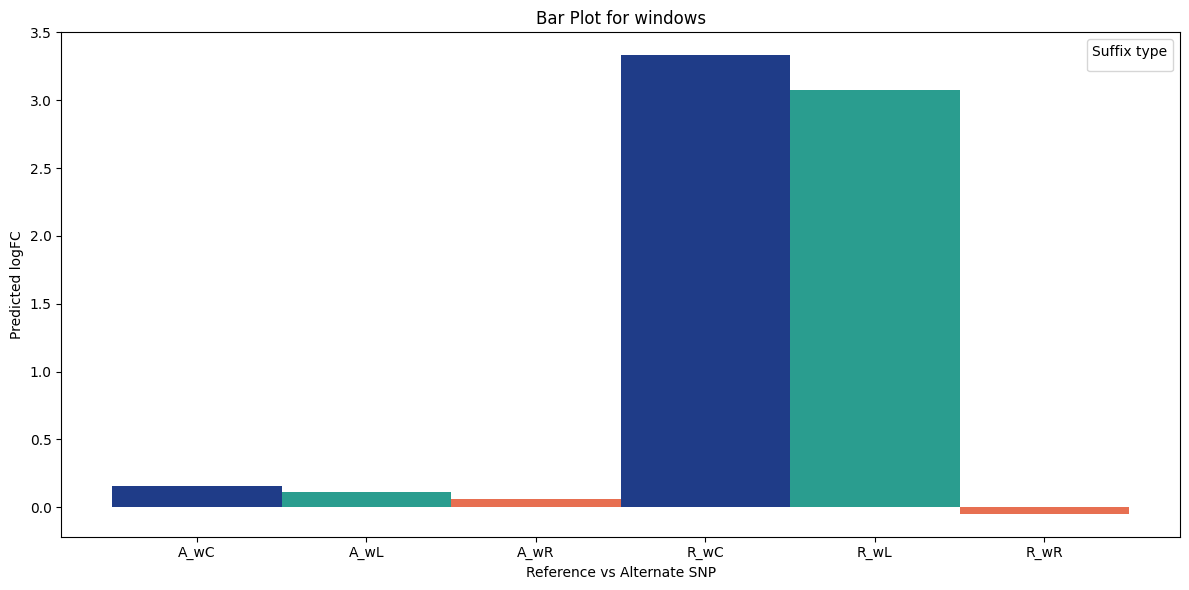

Saved plot: /scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos/windows_barplot.svg


/tmp/ipykernel_2725771/3826862088.py:45: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(handles, labels, title="Suffix type", loc="upper right")


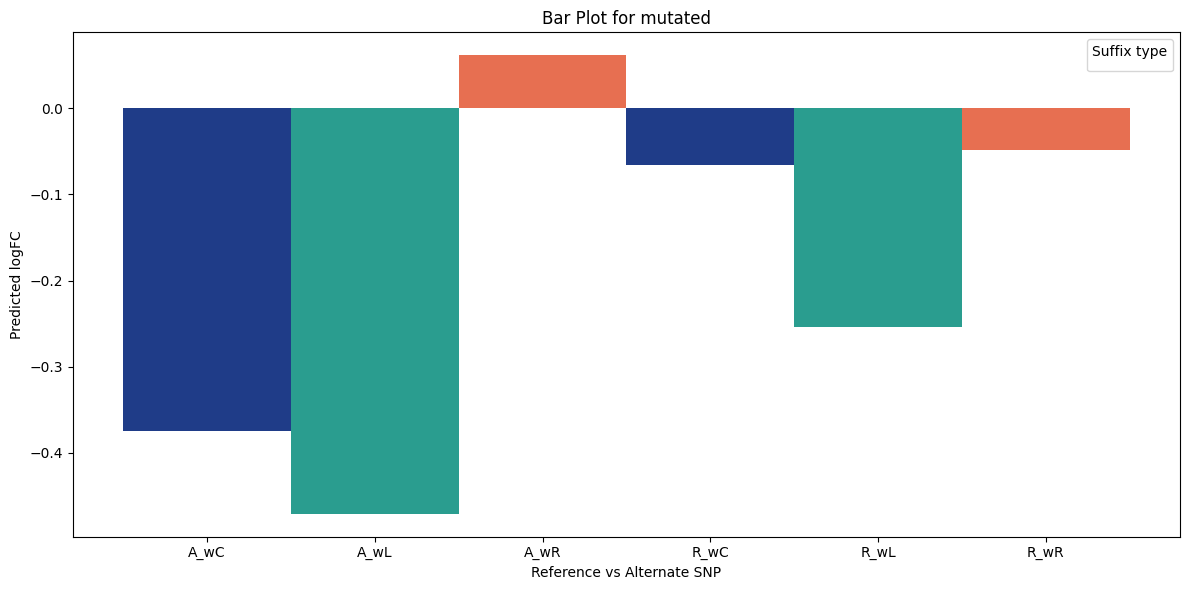

Saved plot: /scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos_mutated/mutated_barplot.svg


/tmp/ipykernel_2725771/3826862088.py:45: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(handles, labels, title="Suffix type", loc="upper right")


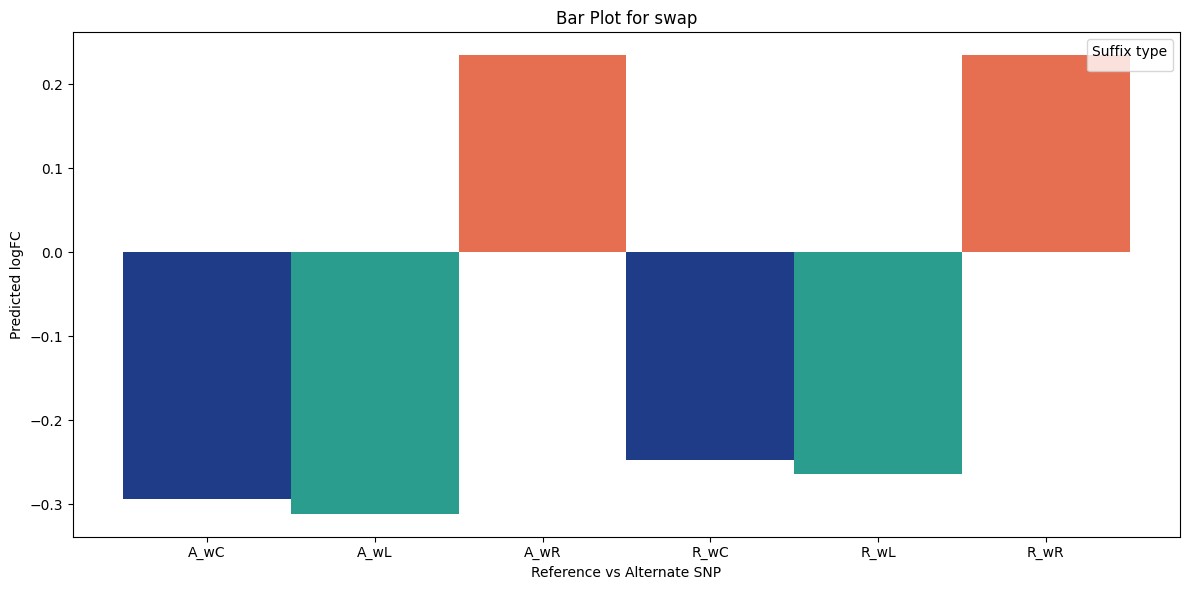

Saved plot: /scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/swap/ism_logos/swap_barplot.svg


/tmp/ipykernel_2725771/3826862088.py:45: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(handles, labels, title="Suffix type", loc="upper right")


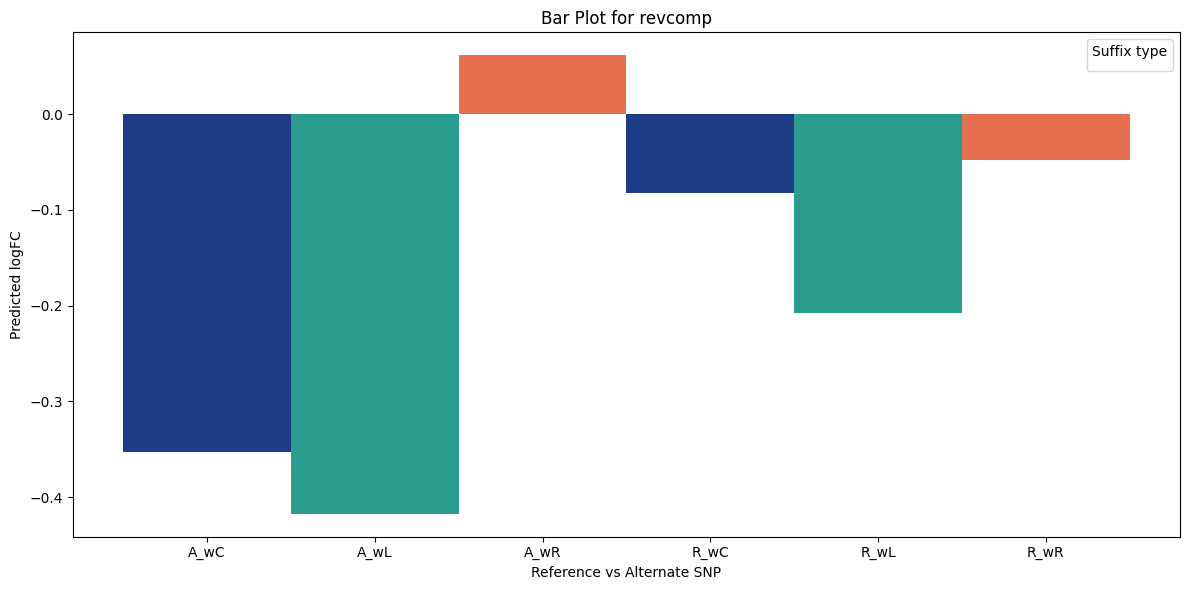

Saved plot: /scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/revcomp/ism_logos/revcomp_barplot.svg


/tmp/ipykernel_2725771/3826862088.py:45: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(handles, labels, title="Suffix type", loc="upper right")


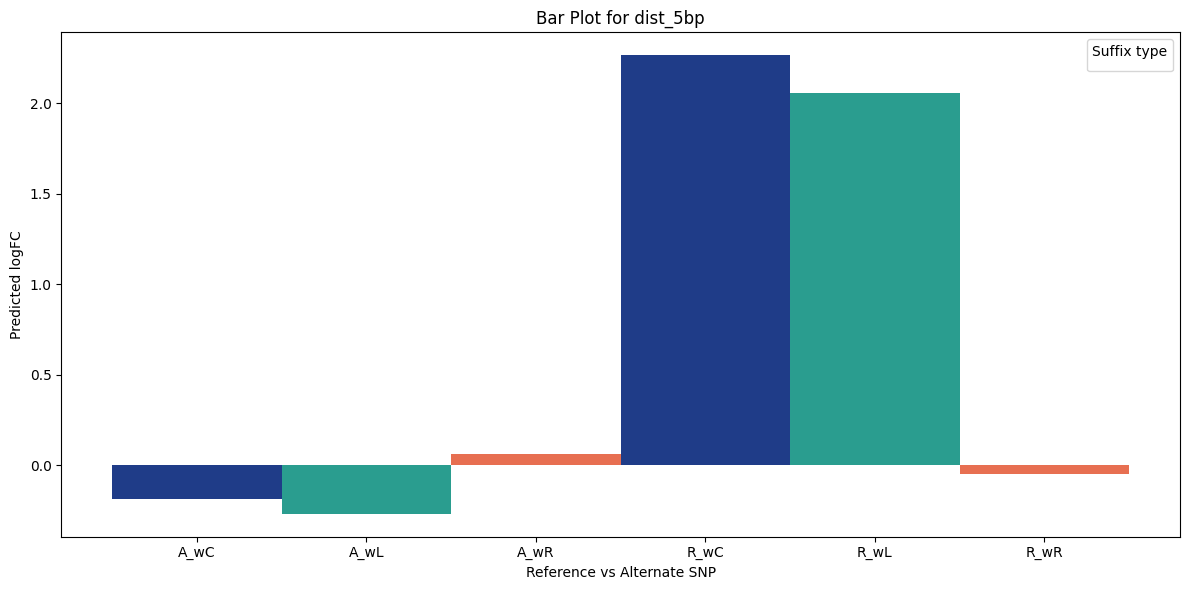

Saved plot: /scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_5bp/ism_logos/dist_5bp_barplot.svg


/tmp/ipykernel_2725771/3826862088.py:45: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(handles, labels, title="Suffix type", loc="upper right")


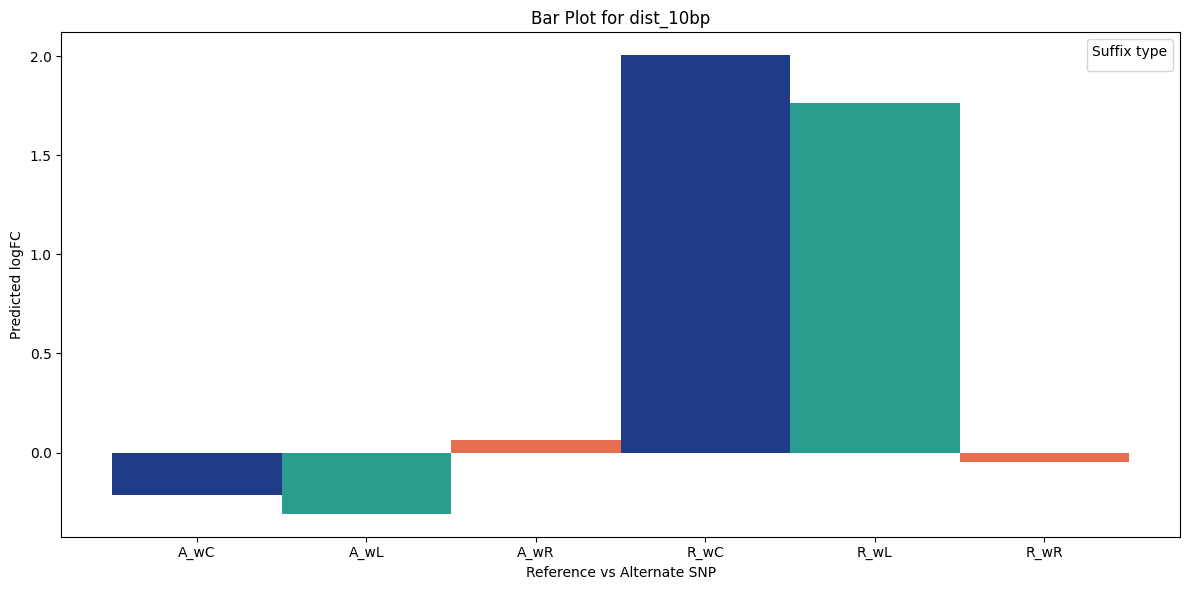

Saved plot: /scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_10bp/ism_logos/dist_10bp_barplot.svg


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# File paths
files = {
    "windows": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos/bar.csv",
    "mutated": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos_mutated/bar.csv",
    "swap": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/swap/ism_logos/bar.csv",
    "revcomp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/revcomp/ism_logos/bar.csv",
    "dist_5bp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_5bp/ism_logos/bar.csv",
    "dist_10bp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_10bp/ism_logos/bar.csv",
}

color_map = {
    "_wC": "#1f3c88",  # navy blue
    "_wR": "#e76f51",  # warm terracotta/orange
    "_wL": "#2a9d8f",  # teal green
}

# Function to determine bar color based on seq_id
def get_color(seq_id):
    for suffix, color in color_map.items():
        if seq_id.endswith(suffix):
            return color
    return "#7f7f7f"  # default grey if no match

# Iterate through files and plot
for name, path in files.items():
    df = pd.read_csv(path)

    # Ensure sorting: R_* first, then A_*
    df['prefix'] = df['seq_id'].str[0]
    df = df.sort_values(by=['prefix', 'seq_id'])

    # Assign colors
    df['color'] = df['seq_id'].apply(get_color)

    plt.figure(figsize=(12, 6))
    plt.bar(df['seq_id'], df['original_pred'], color=df['color'], width=1)

    handles = [plt.Rectangle((0,0),1,1, color=color) for color in color_map.values()]
    labels = [suffix for suffix in color_map.keys()]
    plt.legend(handles, labels, title="Suffix type", loc="upper right")
    # Labels and formatting
    plt.xticks(rotation=0)
    plt.ylabel("Predicted logFC")
    plt.xlabel("Reference vs Alternate SNP")
    plt.title(f"Bar Plot for {name}")
    plt.tight_layout()
    # Save plot in same folder as CSV
    output_path = os.path.join(os.path.dirname(path), f"{name}_barplot.svg")
    plt.savefig(output_path, format="svg")
    plt.show()

    print(f"Saved plot: {output_path}")


### Plot a combined plot ###

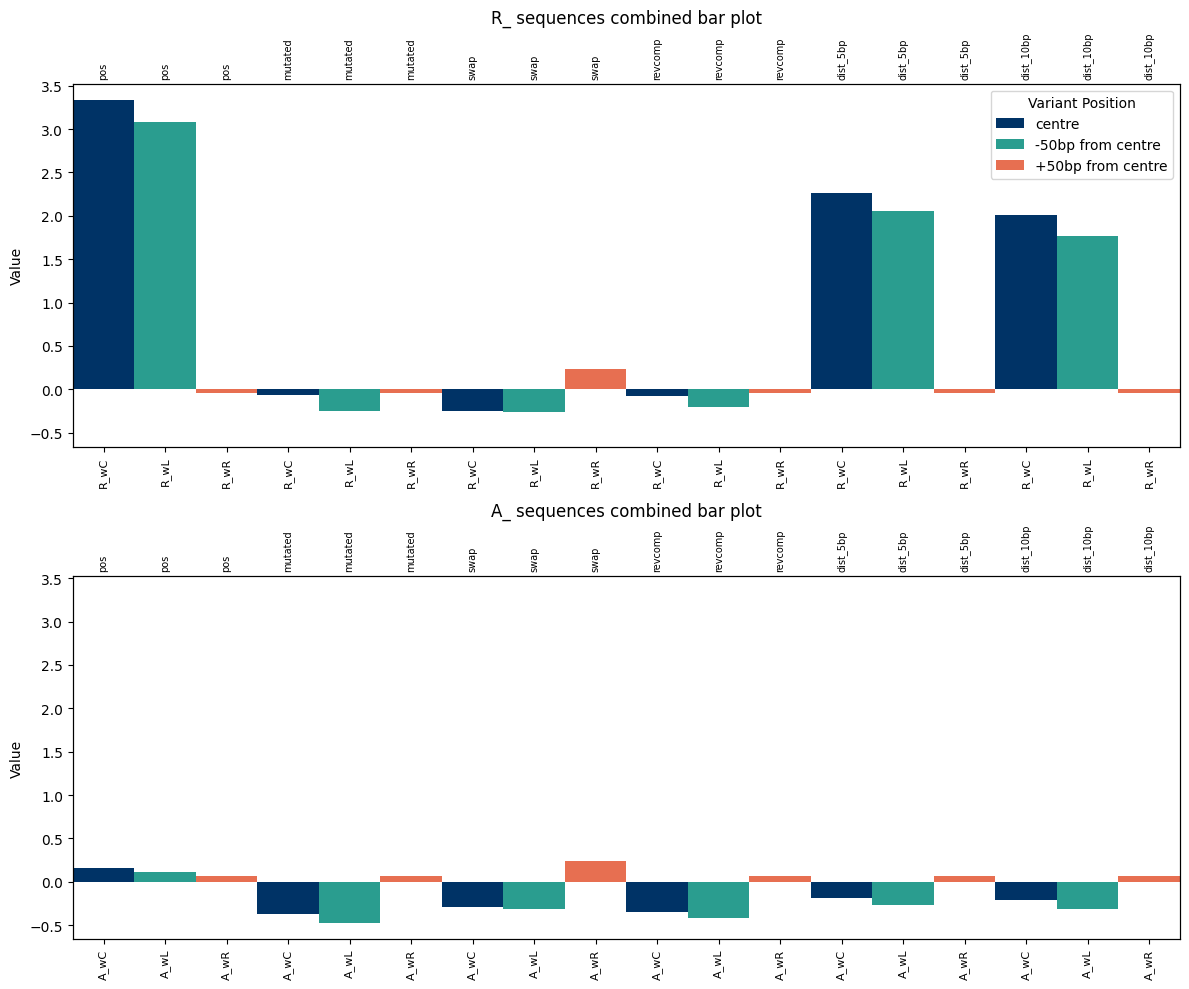

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

paths = {
    "pos": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos/bar.csv",
    "mutated": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos_mutated/bar.csv",
    "swap": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/swap/ism_logos/bar.csv",
    "revcomp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/revcomp/ism_logos/bar.csv",
    "dist_5bp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_5bp/ism_logos/bar.csv",
    "dist_10bp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_10bp/ism_logos/bar.csv"
}

color_map = {
    "wC": '#003366',  # navy blue
    "wR": "#e76f51",  # warm orange
    "wL": "#2a9d8f",  # teal
}

# Load and concat all dataframes with a 'source' column
dfs = []
for name, path in paths.items():
    df = pd.read_csv(path)
    df["source"] = name
    dfs.append(df)
combined = pd.concat(dfs, ignore_index=True)

# Assign color based on suffix
def get_color(seq_id):
    for suffix, color in color_map.items():
        if suffix in seq_id:
            return color
    return "#999999"  # fallback grey

combined["color"] = combined["seq_id"].apply(get_color)

# Split into R_ and A_ groups
R_df = combined[combined["seq_id"].str.startswith("R_")].copy().reset_index(drop=True)
A_df = combined[combined["seq_id"].str.startswith("A_")].copy().reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(12, max(len(R_df), len(A_df))*0.15), 10), sharey=True)

def plot_group(ax, df, group_name):
    x = np.arange(len(df))
    bars = ax.bar(x, df["original_pred"], color=df["color"], width=1.0, align='edge')

    ax.set_xticks(x + 0.5)
    ax.set_xticklabels(df["seq_id"], rotation=90, fontsize=8)

    ax.margins(x=0)
    ax.set_xlim(x[0], x[-1] + 1)

    ax.set_ylabel("Value")
    ax.set_title(f"{group_name} sequences combined bar plot")

    # Legend on top plot only
    if group_name == "R_":
        import matplotlib.patches as mpatches
        handles = [
            mpatches.Patch(facecolor="#003366",  label="centre"),  # navy blue
            mpatches.Patch(facecolor="#2a9d8f",  label="-50bp from centre"),  # teal
            mpatches.Patch(facecolor="#e76f51", label="+50bp from centre"),  # warm orange
        ]

        ax.legend(handles=handles, title="Variant Position", loc="upper right")

    # Source labels axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(x + 0.5)
    ax2.set_xticklabels(df["source"], rotation=90, fontsize=7)
    ax2.tick_params(axis='x', length=0)
    for tick in ax2.get_xticklabels():
        tick.set_bbox(None)  # remove background

plot_group(ax1, R_df, "R_")
plot_group(ax2, A_df, "A_")

plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/bars.svg", format="svg")
plt.show()


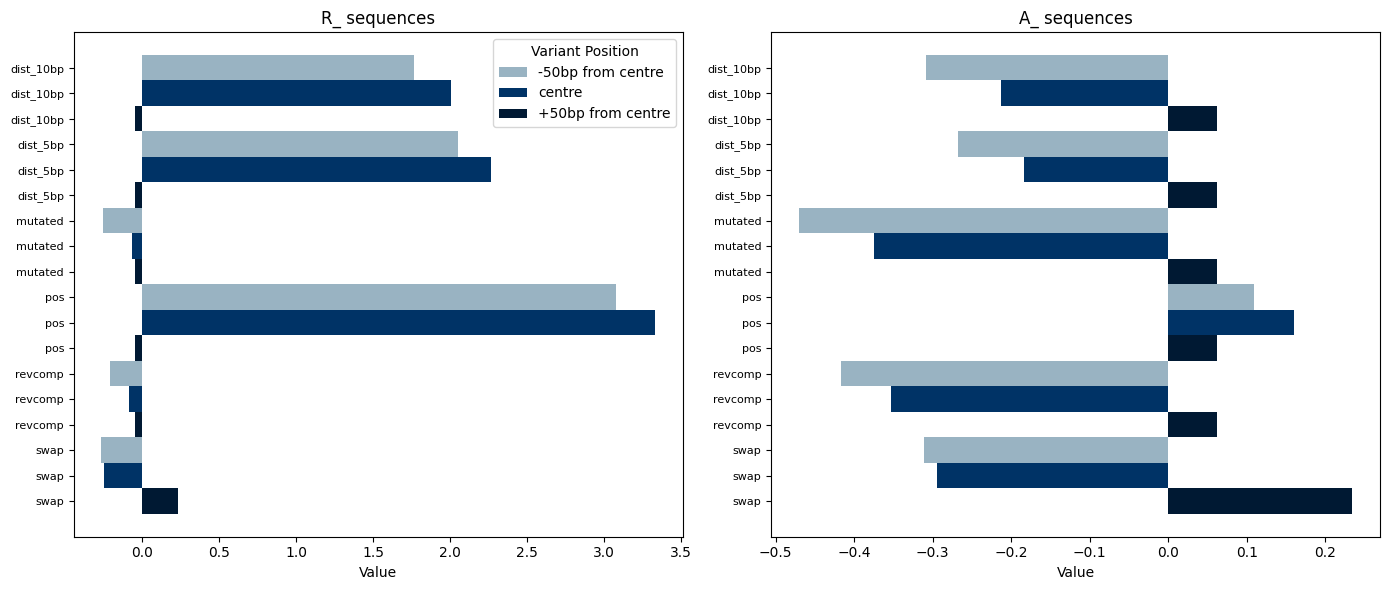

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Your paths and color map
paths = {
    "pos": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos/bar.csv",
    "mutated": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/3_windows/ism_logos_mutated/bar.csv",
    "swap": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/swap/ism_logos/bar.csv",
    "revcomp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/revcomp/ism_logos/bar.csv",
    "dist_5bp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_5bp/ism_logos/bar.csv",
    "dist_10bp": "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/motifs_further_10bp/ism_logos/bar.csv"
}

color_map = {
    "wC": '#003366',  # navy blue
    "wR": "#001933",  
    "wL": "#99B3C2",  # teal
}

# Define desired position order
pos_order = {"wL": -1, "wC": 0, "wR": 1}


dfs = []
for name, path in paths.items():
    df = pd.read_csv(path)
    df["source"] = name
    dfs.append(df)
combined = pd.concat(dfs, ignore_index=True)

# Extract position type from seq_id
def get_pos_type(seq_id):
    for k in pos_order:
        if k in seq_id:
            return k
    return None

combined["pos_type"] = combined["seq_id"].apply(get_pos_type)

# Sort within each background group by pos_order
combined["sort_key"] = combined["pos_type"].map(pos_order)
combined = combined.sort_values(["source", "sort_key"]).reset_index(drop=True)

# Assign color
def get_color(seq_id):
    for suffix, color in color_map.items():
        if suffix in seq_id:
            return color
    return "#999999"

combined["color"] = combined["seq_id"].apply(get_color)

# Split into R_ and A_ groups
R_df = combined[combined["seq_id"].str.startswith("R_")].copy().reset_index(drop=True)
A_df = combined[combined["seq_id"].str.startswith("A_")].copy().reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, max(6, max(len(R_df), len(A_df)) * 0.2)), sharex=False
)

def plot_group(ax, df, group_name):
    y = np.arange(len(df))
    ax.barh(y, df["original_pred"], color=df["color"], height=1.0, align='edge')

    ax.set_yticks(y + 0.5)
    ax.set_yticklabels(df["source"], fontsize=8)
    ax.invert_yaxis()  # highest at top

    ax.set_xlabel("Value")
    ax.set_title(f"{group_name} sequences")

    if group_name == "R_":
        handles = [
            
            mpatches.Patch(facecolor="#99B3C2", label="-50bp from centre"),
            mpatches.Patch(facecolor="#003366", label="centre"),
            mpatches.Patch(facecolor="#001933", label="+50bp from centre"),
        ]
        ax.legend(handles=handles, title="Variant Position", loc="best")

plot_group(ax1, R_df, "R_")
plot_group(ax2, A_df, "A_")

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/bars_horizontal.svg",
    format="svg"
)
plt.show()


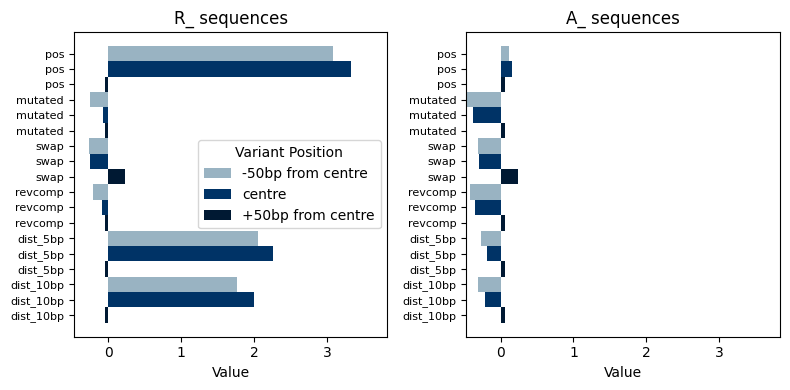

In [23]:
# Define desired order of sources and positions
source_order = {name: i for i, name in enumerate(paths.keys())}
pos_order = {"wL": -1, "wC": 0, "wR": 1}

# Extract position type
def get_pos_type(seq_id):
    for k in pos_order:
        if k in seq_id:
            return k
    return None

combined["pos_type"] = combined["seq_id"].apply(get_pos_type)

# Sorting key: first by source order, then position order
combined["source_sort"] = combined["source"].map(source_order)
combined["pos_sort"] = combined["pos_type"].map(pos_order)
combined = combined.sort_values(["source_sort", "pos_sort"]).reset_index(drop=True)

# Assign colors
def get_color(seq_id):
    for suffix, color in color_map.items():
        if suffix in seq_id:
            return color
    return "#999999"

combined["color"] = combined["seq_id"].apply(get_color)

# Split groups
R_df = combined[combined["seq_id"].str.startswith("R_")].copy().reset_index(drop=True)
A_df = combined[combined["seq_id"].str.startswith("A_")].copy().reset_index(drop=True)

# Plotting function
x_min = min(R_df["original_pred"].min(), A_df["original_pred"].min())
x_max = max(R_df["original_pred"].max(), A_df["original_pred"].max()) + 0.5

def plot_group(ax, df, group_name):
    y = np.arange(len(df))
    ax.barh(y, df["original_pred"], color=df["color"], height=1.0, align='edge')

    ax.set_yticks(y + 0.5)
    ax.set_yticklabels(df["source"], fontsize=8)  # keep seq_id for uniqueness
    ax.invert_yaxis()

    ax.set_xlabel("Value")
    ax.set_title(f"{group_name} sequences")

    if group_name == "R_":
        handles = [
            mpatches.Patch(facecolor="#99B3C2", label="-50bp from centre"),
            mpatches.Patch(facecolor="#003366", label="centre"),
            mpatches.Patch(facecolor="#001933", label="+50bp from centre"),
        ]
        ax.legend(handles=handles, title="Variant Position", loc="best")

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(8, max(4, max(len(R_df), len(A_df)) * 0.2)), sharex=False
)

plot_group(ax1, R_df, "R_")
plot_group(ax2, A_df, "A_")
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/ISM/bars_horizontal.svg",
    format="svg"
)
plt.show()
